# Data Mining / Prospecção de Dados

## Sara C. Madeira, 2025/2026

# Project 2 - Classification in Temporal Data using Sequential Pattern Mining

## Logistics 
**_Read Carefully_**

**Students should work in teams of 3 people**. 

Groups with less than 3 people might be allowed (with valid justification), but will not have better grades for this reason. 

The quality of the project will dictate its grade, not the number of people working.

**The project's solution should be uploaded in Moodle before the end of `June, 7th (23:59)`.** 

Students should **upload a `.zip` file** containing a folder with all the files necessary for project evaluation. 
Groups should be registered in [Moodle](https://moodle.ciencias.ulisboa.pt/mod/groupselect/view.php?id=299650) and the `zip` file should be identified as `PDnn.zip` where `nn` is the number of your group.

**It is mandatory to produce a Jupyter notebook containing code and text/images/tables/etc describing the solution and the results. Projects not delivered in this format will not be graded. You can use `PD_202526_P2.ipynb` as template. In your `.zip` folder you should also include an HTML version of your notebook with all the outputs.**

**Decisions should be justified and results should be critically discussed.** 

Remember that **your notebook should be as clear and organized as possible**, that is, **only the relevant code and experiments should be presented, not everything you tried and did not work, or is not relevant** (that can be discussed in the text, if relevant)! Tables and figures can be used together with text to summarize results and conclusions, improving understanding, readability and concision. **More does not mean better! The target is quality not quantity!**

_**Project solutions containing only code and outputs without discussions will achieve a maximum grade of 10 out of 20.**_

## Dataset and Tools

Amyotrophic Lateral Sclerosis (ALS) is a devastating neurodegenerative disease causing rapid degeneration of motor neurons and usually leading to death by respiratory failure. Since there is no cure, treatment’s goal is to improve symptoms and prolong survival. Non-invasive Ventilation (NIV) has been shown to extend life expectancy and improve quality of life, thus it is key to effectively predict if ALS patients will be eligible for NIV in the near future based on disease progression. In this context, Martins et al. (2021) proposed to learn prognostic models using disesase progression patterns (https://ieeexplore.ieee.org/document/9426397/), and formulated the following prognostic prediction problem (schematized in Figure below): given a specific ALS patient static data collected at diagnosis and temporal data from disease follow-up, can we effectively use these clinical evaluations to predict if this patient will require NIV within k days of the last evaluation?

<img src="prognostic_problem.png" alt="Prognostic Prediction" style="width: 500px;"/>

**In this project, we will perform a reduced part of the work published by Martins et al. to learn a machine learning model (classifier) able to predict the need for NIV in a time window of 180 days given static and temporal data and sequential patterns as features.**

The dataset to be analysed `Dataset_Static_Temporal_Evolution_NIV_180.csv`was obtained after extensive preprocessing from the Lisbon ALS database, containing clinical data from ALS patients collected during their follow-up at the hospital. This file has `Static` and `Temporal` data, together with `class` labels, indicating the `Evolution` (yes/no) to a clinical status where Non-Invasive Ventilation (NIV) is required after 180 days from the specific clinical appointment. 

<img src="dataset_example.png" alt="Dataset with Static, Temporal and Class Labels" style="width: 1000px;"/>

1. `Static Features` - each row is a patient with a REF id described by a set of features collected at diagnosis time (`Gender`, ... `C9orf72`). These features are called static since they are not collected over time. They are repeated in each row represented

<img src="static_example.png" alt="Temporal Data" style="width: 500px;"/>

2. `Temporal Features` - each patient has a set of rows (snapshots), each corresponding to a visit at the hospital and the values collected for a set of temporal features collected over time (`ALSFRSb`, ..., `ALSFRS-R`). The rows per patient REF are sorted in chonologic order, such that the first row and the last row of a REF correspond, respectively to the data collected in the first visit (diagnosis) and last visit at the hospital. In the example below, the patient REF=9 has temporal data describing 5 clinical evaluations (time-points).

<img src="temporal_example.png" alt="Temporal Data" style="width: 500px;"/>

3. `Class Label` - each patient has a set of rows with the true value of NIV (yes or no) 180 days in the future (`Evolution`). These are the class labels to be used later to train the classifier. Patient REF=9 does not evolve to need NIV 180 days after time-points 1 (diagnosis) to 4 but evolves to NIV 180 days after time-point 5.

<img src="NIV_evolution_example.png" alt="Temporal Data" style="width: 100px;"/>

In this context, the project has **2 main tasks**:
1. Learn disease progression patterns from the temporal data using temporal pattern mining 
2. Learn a classifier to predict NIV using temporal patterns as features together with the static features


**In this project you should use [Python 3](https://www.python.org), [Jupyter Notebook](http://jupyter.org), [`SPMF`](https://www.philippe-fournier-viger.com/software.php) for temporal pattern mining (**use the modified version `spmf_PD.jar`**), and [`Scikit-learn`](https://scikit-learn.org/stable/) for classification.**


## Team Identification

**GROUP PD10**

Students:

* Maja Skwaroń - 66083
* Student 2 - n_student2
* Student 3 - n_student3

## 1. Learn disease progression patterns from the temporal data using temporal pattern mining

In this first task you should load and preprocessed the dataset `Dataset_Static_Temporal_Evolution_NIV_180.csv` in order to compute sequential patterns for each patient. 

For that, you first need to load and preprocess this dataset and then transform the **temporal data** into a **sequence database**.

You should consider **a minimum of 2 time-points** and a **maximum of 5 time-points** per patient.

The sequential pattern mining algorithm `Fourier08` (https://www.philippe-fournier-viger.com/spmf/ClosedSequentialPatterns_TimeConstraints.php), an extension of `PrefixSpan` able to **deal with time** and compute **close patterns**, should be used. Remember to use version `spmf_PD.jar` so you can list the sequential patterns together with the list of patients where they occur.

### 1.1. Load and Preprocess Dataset

- Remove all patients (REFs) with missing values in the temporal features.
- Remove all patients with less than 2 time-points.
- For the patients with more than 5 time-points, keep only the first 5.
- In order to reduce the number of patterns to be generated agregate the values of the temporal features using the following intervals (4 intervals for each feature as in Martins et al): 
  1) Intervals for `ALSFRSb, ALSFRSsUL, ALSFRSsT, ALSFRSsLL, and R: <4 [4,8[ [8,12[ 12`
  3) Intervals for `ALSFRS-R: <12  [12,24[  [24,36[  >=36`

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv('Dataset_Static_Temporal_Evolution_NIV_180.csv')

print(f"Dataset shape: {df.shape}")
print(f"Total unique patients (REFs): {df['REF'].nunique()}")

# Define temporal and static feature columns
TEMPORAL_COLS = ['ALSFRSb', 'ALSFRSsUL', 'ALSFRSsT', 'ALSFRSsLL', 'R', 'ALSFRS-R']
STATIC_COLS   = ['Gender', 'Age at onset (years)', 'Revised El Escorial Criteria',
                 'Onset', 'Diagnostic delay (months)', 'BMI at 1st visit',
                 'MND familiar history', 'C9orf72']

# Step 1: Remove patients with any missing value in temporal features 
refs_with_missing = df[df[TEMPORAL_COLS].isnull().any(axis=1)]['REF'].unique()
print(f"\nPatients with missing temporal values: {len(refs_with_missing)}")

df_clean = df[~df['REF'].isin(refs_with_missing)].copy()
print(f"Patients remaining after step 1: {df_clean['REF'].nunique()}")

# Step 2: Remove patients with fewer than 2 time-points 
timepoints_per_patient = df_clean.groupby('REF').size()
refs_lt2 = timepoints_per_patient[timepoints_per_patient < 2].index
print(f"\nPatients with fewer than 2 time-points: {len(refs_lt2)}")

df_clean = df_clean[~df_clean['REF'].isin(refs_lt2)].copy()
print(f"Patients remaining after step 2: {df_clean['REF'].nunique()}")

# Step 3: For patients with more than 5 time-points, keep only the first 5 
df_clean = df_clean.groupby('REF').head(5).copy()

timepoints_after = df_clean.groupby('REF').size()
print(f"\nPatients remaining after step 3: {df_clean['REF'].nunique()}")
print(f"Max time-points per patient: {timepoints_after.max()}")
print(f"Time-point distribution:\n{timepoints_after.value_counts().sort_index()}")

# Step 4: Change temporal features into intervals 

# Subscores ALSFRSb, ALSFRSsUL, ALSFRSsT, ALSFRSsLL, R: range 0-12, 4 bins
SUBSCORE_COLS = ['ALSFRSb', 'ALSFRSsUL', 'ALSFRSsT', 'ALSFRSsLL', 'R']
SUBSCORE_BINS   = [float('-inf'), 4, 8, 12, float('inf')]
SUBSCORE_LABELS = ['0', '1', '2', '3']  # 0=worst (<4), 3=best (=12)

# Total score ALSFRS-R: range 0-48, 4 bins
TOTAL_BINS   = [float('-inf'), 12, 24, 36, float('inf')]
TOTAL_LABELS = ['0', '1', '2', '3']

for col in SUBSCORE_COLS:
    df_clean[col + '_disc'] = pd.cut(df_clean[col], bins=SUBSCORE_BINS,
                                     labels=SUBSCORE_LABELS, right=False)

df_clean['ALSFRS-R_disc'] = pd.cut(df_clean['ALSFRS-R'], bins=TOTAL_BINS,
                                    labels=TOTAL_LABELS, right=False)

DISC_COLS = [c + '_disc' for c in SUBSCORE_COLS] + ['ALSFRS-R_disc']

# Verification: value counts per discretized feature
print("=== Value distribution per discretized feature ===")
print("(Labels: 0=worst, 1=moderate, 2=mild, 3=best/normal)\n")
for col in DISC_COLS:
    counts = df_clean[col].value_counts().sort_index()
    print(f"{col}:")
    print(counts.to_string())
    print()

# Sanity check: show original vs discretized for a sample patient
sample_ref = df_clean['REF'].iloc[0]
print(f"=== Sample patient REF={sample_ref}: original vs discretized ===")
sample = df_clean[df_clean['REF'] == sample_ref][TEMPORAL_COLS + DISC_COLS]
print(sample.to_string(index=False))


Dataset shape: (4322, 16)
Total unique patients (REFs): 1042

Patients with missing temporal values: 267
Patients remaining after step 1: 775

Patients with fewer than 2 time-points: 219
Patients remaining after step 2: 556

Patients remaining after step 3: 556
Max time-points per patient: 5
Time-point distribution:
2    154
3    113
4     66
5    223
Name: count, dtype: int64
=== Value distribution per discretized feature ===
(Labels: 0=worst, 1=moderate, 2=mild, 3=best/normal)

ALSFRSb_disc:
ALSFRSb_disc
0      62
1     209
2     634
3    1121

ALSFRSsUL_disc:
ALSFRSsUL_disc
0     281
1    1008
2     737
3       0

ALSFRSsT_disc:
ALSFRSsT_disc
0     312
1    1276
2     438
3       0

ALSFRSsLL_disc:
ALSFRSsLL_disc
0    610
1    959
2    457
3      0

R_disc:
R_disc
0       0
1       0
2     467
3    1559

ALSFRS-R_disc:
ALSFRS-R_disc
0       1
1      52
2     464
3    1509

=== Sample patient REF=2: original vs discretized ===
 ALSFRSb  ALSFRSsUL  ALSFRSsT  ALSFRSsLL    R  ALSFRS-R A

### Discussion

**Step 1**  
The temporal features (`ALSFRSb`, `ALSFRSsUL`, `ALSFRSsT`, `ALSFRSsLL`, `R`, `ALSFRS-R`) are the ALSFRS subscores collected at each hospital visit. Missing values in any of these columns would make a time-point incomplete and unrepresentable in the sequence database, therefore rather than imputing or dropping individual rows (which would disrupt temporal ordering), the entire patient is removed.

**Step 2**  
Sequential pattern mining requires sequences of length ≥ 2 to be meaningful, because a single time-point yields no temporal evolution and cannot produce any patterns of length > 1. Patients with only one visit were therefore excluded.

**Step 3**  
To limit combinatorial explosion in the sequence database and to align with Martins et al. (2021), sequences were capped at 5 time-points. When a patient has more than 5 visits, we kept only the first 5 (chronological order is preserved in the dataset), which captures early disease progression from diagnosis onward.


**Step 4**  
The continuous ALSFRS subscores were binned into 4 ordered categories (0=worst, 3=best) so that sequential pattern mining operates on discrete symbols rather than raw numbers. Without this step, two patients with scores 7.8 and 8.1 would be treated as having completely different items, leading to an explosion of near-duplicate patterns and poor generalization. The bin boundaries follow Martins et al. (2021):
- Subscores (`ALSFRSb`, `ALSFRSsUL`, `ALSFRSsT`, `ALSFRSsLL`, `R`): `<4` → 0, `[4,8[` → 1, `[8,12[` → 2, `=12` → 3
- Total score (`ALSFRS-R`): `<12` → 0, `[12,24[` → 1, `[24,36[` → 2, `≥36` → 3

Additionally, the output above shows the distribution of patients across bins for each feature and a sample patient's original vs. discretized values to verify correctness.


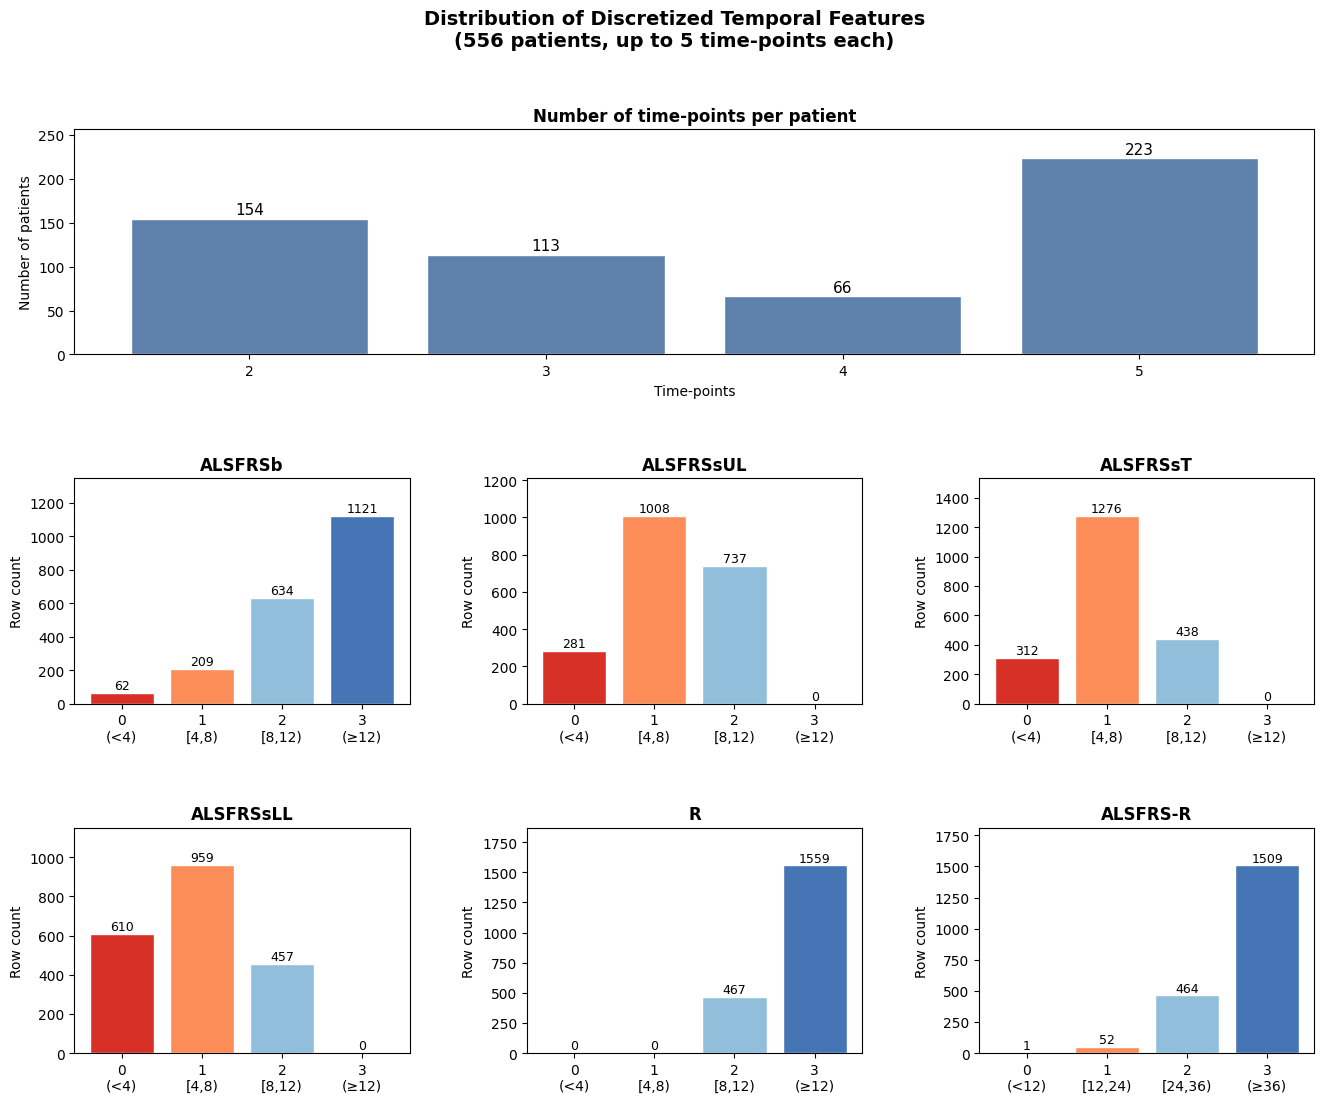

In [2]:
# visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

BIN_LABELS = ['0\n(<4)', '1\n[4,8)', '2\n[8,12)', '3\n(≥12)']
BIN_LABELS_TOTAL = ['0\n(<12)', '1\n[12,24)', '2\n[24,36)', '3\n(≥36)']
COLORS = ['#d73027', '#fc8d59', '#91bfdb', '#4575b4']  # red→blue = worst→best

fig = plt.figure(figsize=(16, 12))
fig.suptitle('Distribution of Discretized Temporal Features\n(556 patients, up to 5 time-points each)',
             fontsize=14, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

# time-point distribution 
ax_tp = fig.add_subplot(gs[0, :])
tp_counts = df_clean.groupby('REF').size().value_counts().sort_index()
bars = ax_tp.bar(tp_counts.index.astype(str), tp_counts.values, color='#5e81ac', edgecolor='white')
ax_tp.set_title('Number of time-points per patient', fontweight='bold')
ax_tp.set_xlabel('Time-points')
ax_tp.set_ylabel('Number of patients')
for bar, val in zip(bars, tp_counts.values):
    ax_tp.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val),
               ha='center', va='bottom', fontsize=11)
ax_tp.set_ylim(0, tp_counts.max() * 1.15)

# one subplot per discretized feature
axes_positions = [(1,0),(1,1),(1,2),(2,0),(2,1),(2,2)]
all_disc = SUBSCORE_COLS + ['ALSFRS-R']

for idx, col in enumerate(all_disc):
    disc_col = col + '_disc'
    r, c = axes_positions[idx]
    ax = fig.add_subplot(gs[r, c])

    counts = df_clean[disc_col].value_counts().sort_index()
    labels = BIN_LABELS if col != 'ALSFRS-R' else BIN_LABELS_TOTAL

    bars = ax.bar(labels, counts.values, color=COLORS, edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Row count')
    ax.set_ylim(0, counts.max() * 1.2)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val),
                ha='center', va='bottom', fontsize=9)

plt.savefig('distributions.png', dpi=130, bbox_inches='tight')
plt.show()


**Time-points distribution**
Most patients have either 2 (154) or 5 (223) time-points, with relatively few having 3 or 4. This imbalance may affect pattern mining, with sequences of length 2 generating far fewer and less informative patterns than sequences of length 5.

**Respiratory score (R) and total (ALSFRS-R)**
Both are heavily skewed toward bins 2 and 3, meaning nearly all patients still have good respiratory function at the time-points we're using. This makes sense because the dataset captures visits before NIV is needed. However, it also means there's very little variability in R across patients, so sequential patterns involving R will be almost uniform and won't discriminate well between classes.

**(ALSFRSsUL), (ALSFRSsT), and (ALSFRSsLL)**
None of these have any patients in bin 3 (fully normal, score=12). These features are already impaired for everyone, which makes sense for follow-ups. The distributions are spread across bins 0–2, so they carry more discriminative power for pattern mining.

**Bulbar (ALSFRSb)**
Is the most spread-out distribution, with patients across all 4 bins, which makes it the most informative feature for distinguishing progression patterns.

The skewed R and ALSFRS-R distributions will likely produce patterns that are near-constant across patients (everyone in bin 2–3), which adds noise rather than signal to the classifier, therefore we might end up with many patterns that occur in almost all patients and are therefore useless as discriminative features. The more variable features (ALSFRSb and ALSFRSsLL) are features where meaningful progression patterns are more likely to emerge. This will have to be nonetheless verified with the formal analysis.

### 1.2. Compute the Sequence Database

Note that items should have the form `Feature=value` and you should have a sequence database with as many sequences as patients. 

Each sequence encodes the several time-points (maximum 5) of each patient.

See `Fourier08` example (https://www.philippe-fournier-viger.com/spmf/ClosedSequentialPatterns_TimeConstraints.php) to undertand the format received by the algorithm, specially the time information. 

Remember also the end of the example with PrefixSpan (https://www.philippe-fournier-viger.com/spmf/PrefixSpan.php) to understand how to use strings instead of integers to encode items .

In [ ]:
# Build item vocabulary: each unique "Feature=value" string gets an integer ID
item_to_id = {}
id_counter = [1]  

def get_item_id(feature_value_str):
    if feature_value_str not in item_to_id:
        item_to_id[feature_value_str] = id_counter[0]
        id_counter[0] += 1
    return item_to_id[feature_value_str]

# Pre-populate the vocabulary in a consistent order
for col in SUBSCORE_COLS:
    for val in ['0', '1', '2', '3']:
        get_item_id(f"{col}={val}")

for val in ['0', '1', '2', '3']:
    get_item_id(f"ALSFRS-R={val}")

id_to_item = {v: k for k, v in item_to_id.items()}

# Build the sequence database
sequences = []  

for ref, group in df_clean.groupby('REF', sort=False):
    itemsets = []
    for t, (_, row) in enumerate(group.iterrows()):
        items = []
        for col in SUBSCORE_COLS:
            items.append(get_item_id(f"{col}={row[col + '_disc']}"))
        items.append(get_item_id(f"ALSFRS-R={row['ALSFRS-R_disc']}"))
        items_sorted = sorted(items) 
        itemset_str = f"<{t}> " + " ".join(map(str, items_sorted)) + " -1"
        itemsets.append(itemset_str)
    sequence_str = " ".join(itemsets) + " -2"
    sequences.append((ref, sequence_str))

# Write the SPMF input file
output_path = "sequence_database.txt"

with open(output_path, "w") as f:
    # map integer IDs back to Feature=value strings
    f.write("@CONVERTED_FROM_TEXT\n")
    for item_id, item_str in sorted(id_to_item.items()):
        f.write(f"@ITEM={item_id}={item_str}\n")
    f.write("@ITEM=-1=|\n")
    for ref, seq in sequences:
        f.write(seq + "\n")

print(f"Sequence database written to '{output_path}'")
print(f"Total sequences (patients): {len(sequences)}")
print(f"Total unique items (Feature=value pairs): {len(item_to_id)}")
print(f"\nItem vocabulary:")
for item_id, item_str in sorted(id_to_item.items()):
    print(f"  {item_id:2d} = {item_str}")

# Show first 3 sequences in human-readable form for verification
print("\n=== First 3 sequences (human-readable) ===")
for ref, seq in sequences[:3]:
    print(f"\nREF={ref}:")
    for part in seq.replace(" -2", "").split("-1"):
        part = part.strip()
        if not part:
            continue
        # Extract timestamp and item IDs
        ts_end = part.index(">") + 1
        ts = part[:ts_end]
        item_ids = [int(x) for x in part[ts_end:].split() if x]
        readable = ts + " " + ", ".join(id_to_item[i] for i in item_ids)
        print(f"  {readable}")


Sequence database written to 'sequence_database.txt'
Total sequences (patients): 556
Total unique items (Feature=value pairs): 24

Item vocabulary:
   1 = ALSFRSb=0
   2 = ALSFRSb=1
   3 = ALSFRSb=2
   4 = ALSFRSb=3
   5 = ALSFRSsUL=0
   6 = ALSFRSsUL=1
   7 = ALSFRSsUL=2
   8 = ALSFRSsUL=3
   9 = ALSFRSsT=0
  10 = ALSFRSsT=1
  11 = ALSFRSsT=2
  12 = ALSFRSsT=3
  13 = ALSFRSsLL=0
  14 = ALSFRSsLL=1
  15 = ALSFRSsLL=2
  16 = ALSFRSsLL=3
  17 = R=0
  18 = R=1
  19 = R=2
  20 = R=3
  21 = ALSFRS-R=0
  22 = ALSFRS-R=1
  23 = ALSFRS-R=2
  24 = ALSFRS-R=3

=== First 3 sequences (human-readable) ===

REF=2:
  <0> ALSFRSb=3, ALSFRSsUL=2, ALSFRSsT=1, ALSFRSsLL=1, R=3, ALSFRS-R=3
  <1> ALSFRSb=3, ALSFRSsUL=2, ALSFRSsT=1, ALSFRSsLL=1, R=3, ALSFRS-R=3
  <2> ALSFRSb=3, ALSFRSsUL=2, ALSFRSsT=1, ALSFRSsLL=0, R=3, ALSFRS-R=3
  <3> ALSFRSb=3, ALSFRSsUL=1, ALSFRSsT=1, ALSFRSsLL=0, R=3, ALSFRS-R=3

REF=9:
  <0> ALSFRSb=3, ALSFRSsUL=1, ALSFRSsT=1, ALSFRSsLL=0, R=3, ALSFRS-R=3
  <1> ALSFRSb=3, ALSFRSsUL=0,

### Discussion

Each patient was encoded as one line (sequence) in the SPMF file. Each visit became a timestamped itemset using the visit index as the timestamp (0 = first visit, 1 = second...). Each itemset contains 6 items, one per each discretized temporal feature, in the form `Feature=value`.

Since SPMF internally works with integers, we mapped each `Feature=value` string to a unique integer ID using the `@CONVERTED_FROM_TEXT` header. This means the output patterns will display readable names like `ALSFRSb=2` rather than bare numbers, making them directly interpretable.

Items within each itemset were sorted, as required by SPMF. The 24 possible items (6 features × 4 bins each) form the full vocabulary.

The verification revealed that the number of visits per patient is correct. REF=2 has 4 itemsets (<0>–<3>), REF=9 has 5 (<0>–<4>), REF=14 has 2 (<0>–<1>). All within the [2, 5] range we enforced. Additioanlly, it confirmed that item format is correct, with every item Feature=value having a discretized label (0–3), never a raw number like 7.8. Timestamps are sequential as required, and they go 0, 1, 2, ... in order for each patient, with no gaps or reversals.

Lastly, a manual cross-check against the earlier sample output, also confirmed the correctness. REF=2's first visit had original scores 12.0, 8.0, 6.0, 4.0, 12.0, 42.0 which mapped to bins 3, 2, 1, 1, 3, 3. Here at <0> we see exactly ALSFRSb=3, ALSFRSsUL=2, ALSFRSsT=1, ALSFRSsLL=1, R=3, ALSFRS-R=3.


### 1.3. Compute Sequential Patterns

Use `Fourier08` to compute the closed sequential patterns. Trivial patterns of length 1 should be discarded.

Note that later you need to know what are the sequences (patients) where the patterns occur (the algorithm can output that info).

In [2]:
import subprocess
import os
import re
import pandas as pd

NOTEBOOK_DIR = os.getcwd()
SPMF_JAR = os.path.join(NOTEBOOK_DIR, 'spmf_PD.jar')
INPUT_FILE = os.path.join(NOTEBOOK_DIR, 'sequence_database.txt')

print(f"Notebook dir: {NOTEBOOK_DIR}")
print(f"JAR exists: {os.path.exists(SPMF_JAR)}")
print(f"Input file exists: {os.path.exists(INPUT_FILE)}")

THRESHOLDS = [10, 20, 30]
TIME_PARAMS = '0 4 0 100'

results = {}

for minsup in THRESHOLDS:
    output_file = os.path.join(NOTEBOOK_DIR, f'patterns_{minsup}pct.txt')
    cmd = ['java', '-jar', SPMF_JAR, 'run', 'Fournier08-Closed+time',
           INPUT_FILE, output_file, f'{minsup}%'] + TIME_PARAMS.split()

    print(f"\nRunning Fourier08 with minsup={minsup}%...")
    proc = subprocess.run(cmd, capture_output=True, text=True)

    if proc.stdout:
        print(proc.stdout.strip())
    if proc.stderr:
        print("STDERR:", proc.stderr.strip()[:500])

    if not os.path.exists(output_file):
        print(f"ERROR: output file not created for minsup={minsup}%")
        continue

    # Parse output file
    patterns = []
    with open(output_file) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('@'):
                continue
            sup_match = re.search(r'#SUP:\s*(\d+)', line)
            sid_match = re.search(r'#SID:\s*([\d ]+)', line)
            if not sup_match:
                continue
            support = int(sup_match.group(1))
            sids = list(map(int, sid_match.group(1).split())) if sid_match else []
            pattern_str = line[:sup_match.start()].strip()
            items = [t for t in pattern_str.replace('|', ' ').split()
                     if t not in ('-1', '-2', '') and not t.startswith('<')]
            length = len(items)
            patterns.append({'pattern': pattern_str, 'support': support,
                             'length': length, 'sids': sids})

    non_trivial = [p for p in patterns if p['length'] > 1]
    results[minsup] = non_trivial
    print(f"  Total patterns: {len(patterns)} | Non-trivial (length>1): {len(non_trivial)}")

# Summary table
if results:
    print("\n=== Summary ===")
    summary = []
    for minsup, pats in results.items():
        lengths = [p['length'] for p in pats]
        supports = [p['support'] for p in pats]
        summary.append({
            'minsup (%)': minsup,
            'min_support (patients)': round(minsup / 100 * 556),
            '# patterns': len(pats),
            'min length': min(lengths) if lengths else 0,
            'max length': max(lengths) if lengths else 0,
            'avg length': round(sum(lengths)/len(lengths), 1) if lengths else 0,
            'avg support': round(sum(supports)/len(supports), 1) if supports else 0,
        })
    df_summary = pd.DataFrame(summary)
    print(df_summary.to_string(index=False))


Notebook dir: /Users/maja/Documents/Claude/Projects/Data Mining Project 2/data mining project 2/PD_202526_Project2
JAR exists: True
Input file exists: True

Running Fourier08 with minsup=10%...
>/Users/maja/Documents/Claude/Projects/Data Mining Project 2/data mining project 2/PD_202526_Project2/spmf_PD.jar
=============  Algorithm - STATISTICS =============
 Total time ~ 1327836 ms
 Frequent sequences count : 204400

Post-processing to show result in terms of string values.
Post-processing completed.
  Total patterns: 204400 | Non-trivial (length>1): 204384

Running Fourier08 with minsup=20%...
>/Users/maja/Documents/Claude/Projects/Data Mining Project 2/data mining project 2/PD_202526_Project2/spmf_PD.jar
=============  Algorithm - STATISTICS =============
 Total time ~ 78113 ms
 Frequent sequences count : 12453

Post-processing to show result in terms of string values.
Post-processing completed.
  Total patterns: 12453 | Non-trivial (length>1): 12437

Running Fourier08 with minsup=30

### Discussion

The code runs Fourier08 three times with minsup = 10%, 20%, and 30%, saving the output for each. Trivial patterns of length 1 were filtered out since they capture a state at a single time-point rather than a progression over time and carry no discriminative temporal information.

**Time constraint parameters:** `min_time_interval=0, max_time_interval=4, min_whole_interval=0, max_whole_interval=100`. Since timestamps are visit indices (0–4), a max interval of 4 allows patterns to span any two visits. The large `max_whole_interval=100` is recommended by the SPMF documentation when using closed pattern mining to avoid approximate results.

The summary table compares the three selected thresholds on number of patterns generated, pattern lengths, and average support, which will guide the choice of minsup for the classifier.


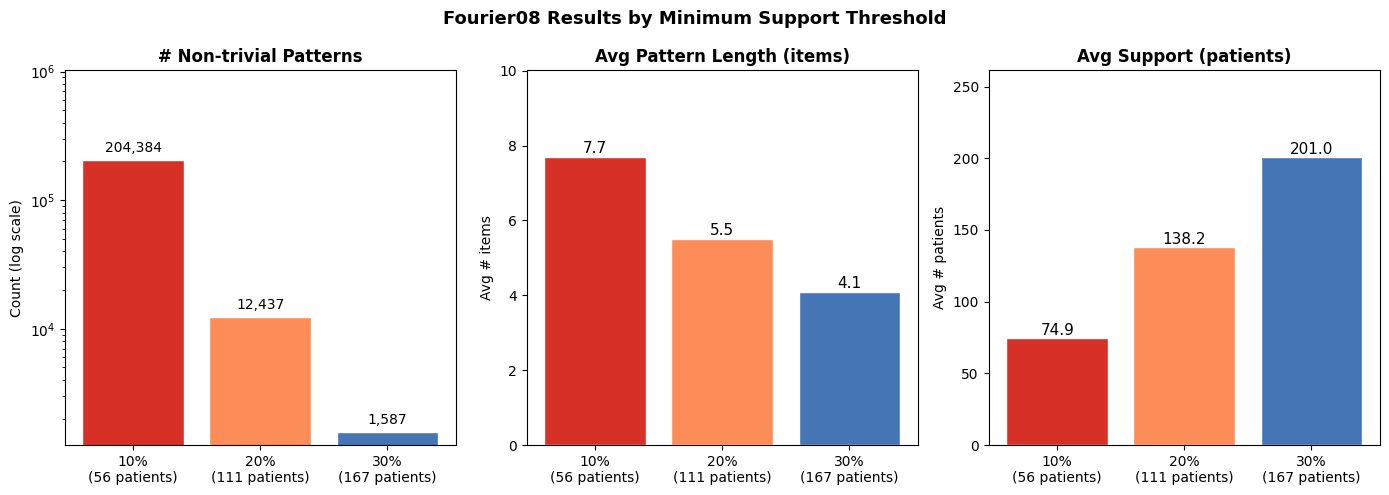

In [1]:
import matplotlib.pyplot as plt
import numpy as np

thresholds = [10, 20, 30]
pattern_counts = [204384, 12437, 1587]
avg_lengths    = [7.7, 5.5, 4.1]
avg_supports   = [74.9, 138.2, 201.0]

x = np.arange(len(thresholds))
labels = [f'{t}%\n({round(t/100*556)} patients)' for t in thresholds]
colors = ['#d73027', '#fc8d59', '#4575b4']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Fourier08 Results by Minimum Support Threshold', fontsize=13, fontweight='bold')

# Plot 1: Number of patterns (log scale)
axes[0].bar(labels, pattern_counts, color=colors, edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_title('# Non-trivial Patterns', fontweight='bold')
axes[0].set_ylabel('Count (log scale)')
for i, v in enumerate(pattern_counts):
    axes[0].text(i, v * 1.15, f'{v:,}', ha='center', fontsize=10)
axes[0].set_ylim(top=max(pattern_counts) * 5)

# Plot 2: Average pattern length
bars = axes[1].bar(labels, avg_lengths, color=colors, edgecolor='white')
axes[1].set_title('Avg Pattern Length (items)', fontweight='bold')
axes[1].set_ylabel('Avg # items')
axes[1].set_ylim(0, max(avg_lengths) * 1.3)
for bar, v in zip(bars, avg_lengths):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.1, str(v), ha='center', fontsize=11)

# Plot 3: Average support
bars = axes[2].bar(labels, avg_supports, color=colors, edgecolor='white')
axes[2].set_title('Avg Support (patients)', fontweight='bold')
axes[2].set_ylabel('Avg # patients')
axes[2].set_ylim(0, max(avg_supports) * 1.3)
for bar, v in zip(bars, avg_supports):
    axes[2].text(bar.get_x() + bar.get_width()/2, v + 2, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('threshold_comparison.png', dpi=130, bbox_inches='tight')
plt.show()


### Discussion

The three plots together tell a clear and consistent story:

**Pattern count (log scale)** — the drop is dramatic. Going from 10% to 30% reduces patterns by 99%, from 204k to 1.6k. 

**Avg pattern length** — higher thresholds produce shorter patterns (7.7 → 4.1 items). This makes intuitive sense: long, complex patterns are rare by nature, so they only survive at low minsup. At 30%, patterns average 4 items, meaning they typically span 2-3 visits and 1-2 features, which gives us simple, interpretable progression we would want.

**Avg support** — inversely, higher thresholds produce patterns shared by more patients (75 → 201). At 30%, the average pattern appears in 201 out of 556 patients (~36%). These are widespread progressions, which means they'll be informative for the classifier because enough patients in both classes will have them.

The 30% patterns are shorter, more general, and shared by more patients than 20% patterns, which is better for a classifier with only 556 samples. 20% gives more patterns with more detail but risks overfitting. Running the classifier on both and comparing them is therefore necessary.

In [2]:
# Inspect sample patterns from 30% output to check clinical interpretability
import os, re

output_file = os.path.join(os.getcwd(), 'patterns_30pct.txt')

patterns_30 = []
with open(output_file) as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith('@'):
            continue
        sup_match = re.search(r'#SUP:\s*(\d+)', line)
        if not sup_match:
            continue
        support = int(sup_match.group(1))
        pattern_str = line[:sup_match.start()].strip()
        items = [t for t in pattern_str.replace('|', ' ').split()
                 if t not in ('-1', '-2', '') and not t.startswith('<')]
        length = len(items)
        if length > 1:
            patterns_30.append({'pattern': pattern_str, 'support': support, 'length': length})

# Sort by support descending
patterns_30.sort(key=lambda x: -x['support'])

print("=== Top 10 most frequent patterns (30% threshold) ===\n")
for i, p in enumerate(patterns_30[:10]):
    print(f"[{i+1}] Support: {p['support']} patients ({round(p['support']/556*100)}%)")
    print(f"     {p['pattern']}\n")

print("\n=== 10 longest patterns (most complex progressions) ===\n")
patterns_by_len = sorted(patterns_30, key=lambda x: -x['length'])
for i, p in enumerate(patterns_by_len[:10]):
    print(f"[{i+1}] Length: {p['length']} items | Support: {p['support']} patients")
    print(f"     {p['pattern']}\n")


=== Top 10 most frequent patterns (30% threshold) ===

[1] Support: 441 patients (79%)
     <0> R=3 ALSFRS-R=3 |

[2] Support: 413 patients (74%)
     <0> R=3 | <1> R=3 |

[3] Support: 412 patients (74%)
     <0> ALSFRSsT=1 ALSFRS-R=3 |

[4] Support: 405 patients (73%)
     <0> ALSFRS-R=3 | <1> ALSFRS-R=3 |

[5] Support: 395 patients (71%)
     <0> ALSFRS-R=3 | <1> R=3 |

[6] Support: 394 patients (71%)
     <0> ALSFRS-R=3 | <1> ALSFRSsT=1 |

[7] Support: 387 patients (70%)
     <0> ALSFRSsT=1 R=3 |

[8] Support: 377 patients (68%)
     <0> R=3 | <1> ALSFRS-R=3 |

[9] Support: 376 patients (68%)
     <0> R=3 ALSFRS-R=3 | <1> R=3 |

[10] Support: 371 patients (67%)
     <0> R=3 ALSFRS-R=3 | <1> ALSFRS-R=3 |


=== 10 longest patterns (most complex progressions) ===

[1] Length: 8 items | Support: 176 patients
     <0> ALSFRSb=3 ALSFRSsT=1 R=3 ALSFRS-R=3 | <1> ALSFRSb=3 ALSFRSsT=1 R=3 ALSFRS-R=3 |

[2] Length: 7 items | Support: 195 patients
     <0> ALSFRSb=3 R=3 ALSFRS-R=3 | <1> ALSFRSb

## 2.  Learn a classifier to predict NIV using temporal patterns as features together with the static features

In this task you should create a training set where each row is a patient and the features are 1) the static features and 2) the sequential patterns computed above. You need also a class label for each patient.

### 2.1. Load/Preprocess the Dataset

- Remember not to consider the patients deleted in step 1.1.
- Note that for each patient the class label you need is the one corresponding to the last time-point you considered in step 1.1.

In [5]:
# Write code in cells like this
# ....

Write text in cells like this ...


### 2.2. Create the Training Set

See Section **3.4 Training Set Creation and Model Learning** of the paper Martins et al (2021). 

Note that in this project the original static features are used thus you only need to compute the distance matrix for the sequencial patterns (which are now features), the static features are used as they are.

**Perform the experiments only for binary matrices**.

In [6]:
# Write code in cells like this
# ....

Write text in cells like this ...


#### 2.1.3. Learn the model

See section **4.1 Model Evaluation** of the paper Martins et al (2021).

Use a `Random-Forest` and present the results for **5-fold cross-validation** (mean+-std). 

Note that the problem is difficult so do not expect high performance.

In [7]:
# Write code in cells like this
# ....

Write text in cells like this 